In [2]:
import dpluspy
import demes 
import moments
import msprime
import numpy as np

In [3]:
# Model paths
model0_file = "notebook_models/graph0.yaml"
params0_file = "notebook_models/params0.yaml"
model1_file = "notebook_models/graph1.yaml"
params1_file = "notebook_models/params1.yaml"

# Parameters
r = 1e-8
u = 1.3e-8
u_std = 2e-9
L = int(5e6)
n_reps = 100
pop_ids = ["popX", "popY"]
samples = {pop_id: 1 for pop_id in pop_ids}
bins = np.logspace(-6, -2, 17)

In [4]:
# Define simulation and D+ parsing functions

def simulate(model_file):
    graph = demes.load(model_file)
    demog = msprime.Demography.from_demes(graph)
    tss = msprime.sim_ancestry(
        demography=demog,
        samples=samples,
        sequence_length=L,
        recombination_rate=r,
        num_replicates=n_reps,
    )
    mtss = [msprime.sim_mutations(ts, np.random.normal(u, u_std)) for ts in tss]
    return mtss


def parse_stats(mtss):
    # Parse statistics from simulation results
    intervals = [[1, L + 1, L + 1]]
    pop_mapping = {x: [x] for x in samples} 
    stats = dict()
    for ii, ts in enumerate(mtss):
        if ii == 0:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=True,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
        else:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=False,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
            for jj in range(len(intervals)):
                stats_ii[(ii, jj)]["denoms"] = stats[(0, jj)]["denoms"]
        stats.update(stats_ii)
    return stats

In [5]:
# Run simulations
mtss = simulate(model1_file)

# Parse statistics and do the bootstrap
stats = parse_stats(mtss)
bootreps = dpluspy.bootstrapping.get_bootstrap_reps(
    stats, num_reps=100, weighted=False)
varcovs = dpluspy.bootstrapping.compute_varcovs(bootreps)
means = dpluspy.bootstrapping.means_across_regions(stats)

In [6]:
def fit_model(graph_file, param_file, output):
    """
    Fit a model, forcing convergence to within 1% LL.
    """
    ll_log = []
    thresh = 0.01
    counter = 0
    max_tries = 10
    converged = False
    while not converged:
        ret = dpluspy.inference.optimize(
            graph_file,
            param_file,
            means,
            varcovs,
            pop_ids=pop_ids,
            bins=bins,
            u=u,
            perturb=0.2,
            method="powell",
            log=True,
            max_iter=100,
            verbose=100,
            output=output,
            overwrite=True
        )
        ll = ret[-1]
        if counter > 0:
            diffs = np.abs((np.array(ll_log) - ll) / ll)
            if np.any(diffs < thresh):
                converged = True
            if counter > max_tries:
                raise ValueError("Failed to obtain convergence")
        ll_log.append(ll)
        counter += 1
    return ret

In [7]:
# Fit the null and underlying (complex) models; force ll1 > ll0
out0 = "notebook_models/model0_fit0.yaml"
out1 = "notebook_models/model0_fit1.yaml"
pnames0, params0, ll0 = fit_model(model0_file, params0_file, out0)
ll1 = -1e10
max_tries = 10
tries = 0
while ll1 <= ll0:
    pnames1, params1, ll1 = fit_model(model1_file, params1_file, out1)
    tries += 1
    if tries > max_tries:
        raise ValueError("Cannot achieve ll1 > ll0")

[21-07-25 12:49:01] Fitting D+ to data for ['popX', 'popY']
Call         LL [       N_A      T_XY       N_X       N_Y]
init          - [  1.21e+04  2.81e+04  3.25e+04  2.57e+03]
100     -466.08 [  1.16e+04  2.67e+04  3.31e+04  4.93e+03]
200     -102.28 [  1.45e+04  2.54e+04   3.3e+04  4.93e+03]
300      -78.88 [  1.59e+04  2.24e+04  2.98e+04  4.62e+03]
400      -64.22 [  1.64e+04  2.12e+04  2.83e+04  4.37e+03]
Finished with flag 0
Log-likelihood:	-63.99
Fitted parameters:
N_A	1.65e+04
T_XY	2.1e+04
N_X	2.81e+04
N_Y	4.32e+03
[21-07-25 12:49:25] Fitting D+ to data for ['popX', 'popY']
Call         LL [       N_A      T_XY       N_X       N_Y]
init          - [  1.32e+04  2.83e+04  3.41e+04  3.04e+03]
100     -812.03 [     1e+04  2.81e+04  3.34e+04  4.98e+03]
200     -107.69 [  1.44e+04  2.57e+04  3.33e+04  4.98e+03]
300      -67.72 [  1.64e+04  2.16e+04  2.89e+04  4.43e+03]
400      -63.99 [  1.65e+04  2.09e+04   2.8e+04  4.32e+03]
Finished with flag 0
Log-likelihood:	-63.99
Fitted parame

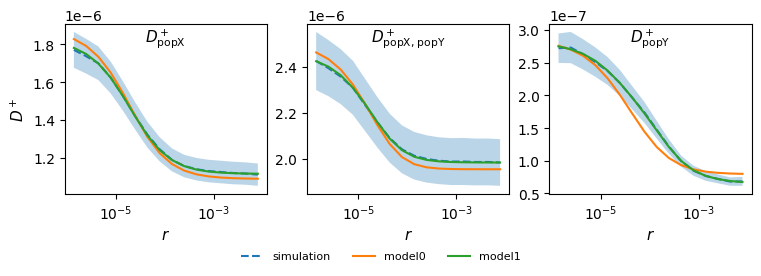

In [8]:
# Plot model fits
model0 = dpluspy.inference.compute_bin_stats(out0, bins=bins, u=u, 
    sampled_demes=pop_ids)
model1 = dpluspy.inference.compute_bin_stats(out1, bins=bins, u=u, 
    sampled_demes=pop_ids)
dpluspy.plotting.plot_D_plus_curves(models=[model0, model1], bins=bins, 
    pop_ids=pop_ids, means=means, varcovs=varcovs, ax_size=2.5,
    labels=["simulation", "model0", "model1"])

In [9]:
# Summarize fitted parameters
print(f"Model 0 (null) ll = {ll0:.3}")
print("Param\tvalue")
for name, val in zip(pnames0, params0):
    print(f"{name}\t{val:.3}")

print(f"\nModel 1 (full, underlying) ll = {ll1:.3}")
print("Param\tvalue")
for name, val in zip(pnames1, params1):
    print(f"{name}\t{val:.3}")

# We have a single nested parameter which is not at a boundary (m_XY)
weights = (0, 1)
D_naive = 2 * (ll1 - ll0)
p_naive = moments.Godambe.sum_chi2_ppf(D_naive, weights=weights)

print("\nNaive (unadjusted) LR statistic:")
print(f"D =\t{D_naive:.3}")
print(f"p =\t{p_naive:.3}")

Model 0 (null) ll = -64.0
Param	value
N_A	1.65e+04
T_XY	2.1e+04
N_X	2.81e+04
N_Y	4.32e+03

Model 1 (full, underlying) ll = -1.24
Param	value
N_A	1.52e+04
T_XY	2.51e+04
N_X	3.04e+04
N_Y	2.96e+03
T_X_Y	5e+03
p_X_Y	0.1

Naive (unadjusted) LR statistic:
D =	1.26e+02
p =	0.0


In [11]:
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

# Compute the LRT adjustment at marginal model 0 parameters
p_lrt = np.concatenate([params0, [params0[1] - 1, 0]])
steps = np.array([params0[1] * 0.01, params1[5] * 0.01])
nested_idx = np.array([4, 5])
bounds = (np.array([0, 0]), np.array([params0[1], 1]))

adj = dpluspy.uncerts.LRT_adjust(p_lrt, model_args, means, varcovs, bootreps, 
    nested_idx, steps=steps, verbose=0, bounds=bounds)
print(p_lrt, steps, nested_idx)
print(f"\nadj =\t{adj:.3}")

[16450.71828078 20966.79172302 28059.32173327  4324.08226353
 20965.79172302     0.        ] [2.09667917e+02 1.00268534e-03] [4 5]

adj =	3.92e+02


In [18]:
# compute the LRT adjustment at zeroed model 0 parameters
p_lrt = np.concatenate([params0, [0.000001, 0]])
nested_idx = np.array([4, 5])

adj = dpluspy.uncerts.LRT_adjust(p_lrt, model_args, means, varcovs, bootreps, 
    nested_idx, steps=steps, verbose=0, bounds=bounds)
print(p_lrt, steps, nested_idx)
print(f"\nadj =\t{adj:.3}")

[1.64507183e+04 2.09667917e+04 2.80593217e+04 4.32408226e+03
 1.00000000e-06 0.00000000e+00] [4.99606705e+01 1.00268534e-03] [4 5]

adj =	9.14


In [19]:
# Compute the LRT adjustment at model 0 parameters
p_lrt = np.concatenate([params0, [params1[4], 0]])
nested_idx = np.array([4, 5])

adj = dpluspy.uncerts.LRT_adjust(p_lrt, model_args, means, varcovs, bootreps, 
    nested_idx, steps=steps, verbose=0, bounds=bounds)
print(p_lrt, steps, nested_idx)
print(f"\nadj =\t{adj:.3}")

[16450.71828078 20966.79172302 28059.32173327  4324.08226353
  4996.06704936     0.        ] [4.99606705e+01 1.00268534e-03] [4 5]

adj =	-0.0552


In [14]:
# Compute the LRT adjustment at fixed-T model 0 parameters
p_lrt = np.concatenate([params0, [params1[4], 0]])
steps = np.array([params1[5] * 0.01])
nested_idx = np.array([5])
bounds = (np.array([0]), np.array([1]))

adj = dpluspy.uncerts.LRT_adjust(p_lrt, model_args, means, varcovs, bootreps, 
    nested_idx, steps=steps, verbose=0, bounds=bounds)
print(p_lrt, steps, nested_idx)
print(f"\nadj =\t{adj:.3}")

[16450.71828078 20966.79172302 28059.32173327  4324.08226353
  4996.06704936     0.        ] [0.00100269] [5]

adj =	0.0652


In [15]:
# Compute the LRT adjustment at model 1 MLE parameters

# Set up complex model arguments
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = params1
steps = params1[-2:] * 0.01
nested_idx = np.array([4, 5])

# Print a summary of the parameter setup
print("Param\tvalue\tnested?\tstep")
nest_idx = 0
for ii, (name, val) in enumerate(zip(pnames1, p_lrt)):
    nested = True if ii in nested_idx else False
    if nested:
        step = f"{steps[nest_idx]:.3}"
        nest_idx += 1
    else:
        step = "---"
    print(f"{name}\t{val:.3}\t{nested}\t{step}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")

Param	value	nested?	step
N_A	1.52e+04	False	---
T_XY	2.51e+04	False	---
N_X	3.04e+04	False	---
N_Y	2.96e+03	False	---
T_X_Y	5e+03	True	50.0
p_X_Y	0.1	True	0.001

adj =	0.0753
D_adj =	9.44
p =	0.00212
